# Step 2 — Task 2: Pseudobulk + Normalize + PCA for Secretory Cells

 For each patient, turn their Secretory cells into a single gene-expression vector
(a "pseudobulk" profile), then reduce dimensionality with PCA so we can:
1. Visualize whether severe vs not-severe patients separate in PC space
2. Use those PCs as features for ML in Task 3

**Why pseudobulk?** Each patient contributes hundreds of Secretory cells. We can't treat
them as independent samples (they share a patient) — that would be data leakage. Instead,
we average across each patient's Secretory cells to get one number per gene per patient.
That gives us a clean **86 patients × ~30,000 genes** matrix, which we then PCA down to
**86 patients × 50 PCs**.

**Why Secretory cells first?** They were the #1 cell type by all three importance methods
(Gini, permutation, SHAP) in Step 1. If gene expression *within* Secretory cells doesn't
carry severity signal beyond composition, none of the cell types will.

## 2.1 — Imports and load filtered data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")

# Load the filtered AnnData saved at the end of Task 1
adata = sc.read_h5ad("step2_covid_filtered.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 38989 × 29961
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'Variant_Group', 'Participant', 'SARSCoV2_PCR_Status', 'Vaccination_Status', 'WHO_Score_at_Peak', 'SingleCell_SARSCoV2_RNA_Status', 'Coarse_Annotation', 'Detailed_Annotation', 'Variant_Vax_Group', 'n_counts', 'n_genes', 'severity'
    uns: 'Coarse_Annotation_colors'
    obsm: 'X_harmony', 'X_pca', 'X_umap'


## 2.2 — Subset to Secretory cells

Filter rows of the AnnData down to just the Secretory cells. We'll use the
coarse annotation here (so cells like `Secretory.SARSCoV2`, `Secretory.S100A9.PI3.CEACAM5`,
etc. all get grouped together 

In [2]:
CELL_TYPE = "Secretory"
adata_sec = adata[adata.obs["Coarse_Annotation"] == CELL_TYPE].copy()

print(f"Total Secretory cells: {adata_sec.n_obs:,}")
print(f"From {adata_sec.obs['Participant'].nunique()} patients")
print(f"\nMatrix shape: {adata_sec.shape}")

Total Secretory cells: 6,656
From 86 patients

Matrix shape: (6656, 29961)


Some patients may have *zero* Secretory cells AND THEY will drop out.

## 2.3 — Cells per patient: do we have enough?

Pseudobulk averages over a patient's cells of a given type. If a patient has only 1–2
Secretory cells, their pseudobulk profile is just noise. 

We'll plot the distribution first to see how many patients we'd lose at various thresholds.

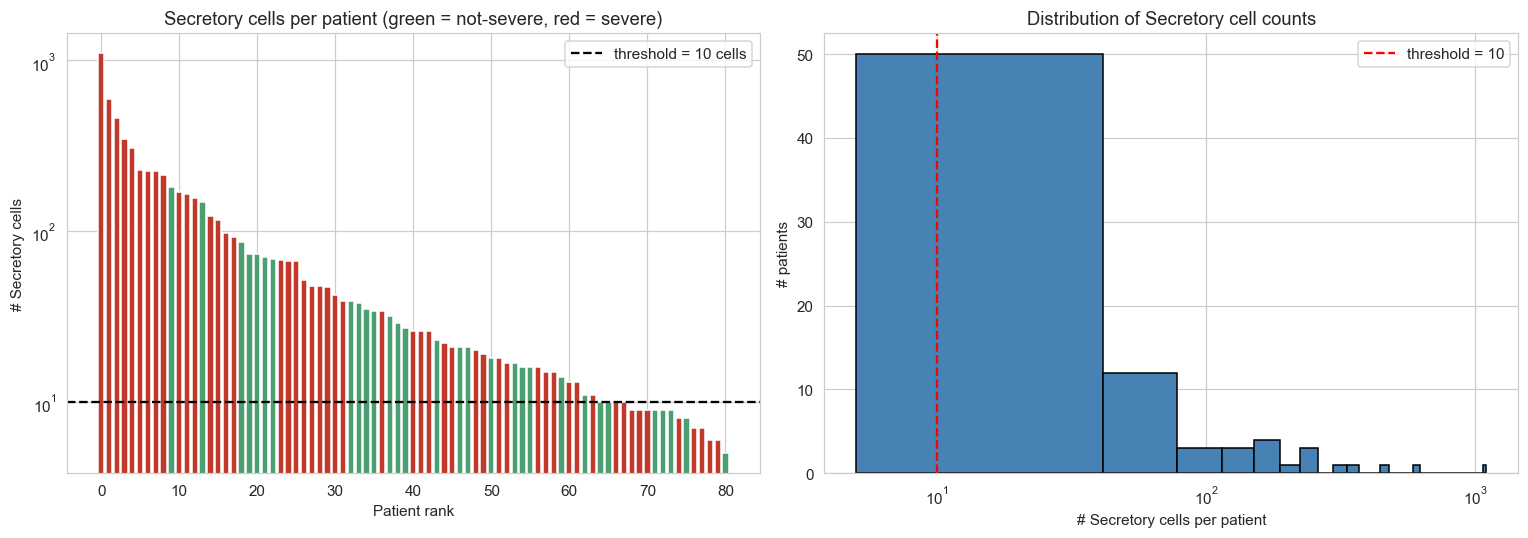

Patient retention at different thresholds:
  ≥   5 cells: 81 / 81 patients kept
  ≥  10 cells: 68 / 81 patients kept
  ≥  20 cells: 49 / 81 patients kept
  ≥  30 cells: 38 / 81 patients kept
  ≥  50 cells: 27 / 81 patients kept


In [22]:
secretory_per_patient = adata_sec.obs["Participant"].value_counts()

# Merge with severity for color-coding
patient_sev = (
    adata_sec.obs.drop_duplicates("Participant")
    .set_index("Participant")["severity"]
)
plot_df = pd.DataFrame({
    "n_cells": secretory_per_patient,
    "severity": patient_sev,
}).sort_values("n_cells", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ranked bar chart
colors = ["#4C9F70" if s == 0 else "#C0392B" for s in plot_df["severity"]]
axes[0].bar(range(len(plot_df)), plot_df["n_cells"], color=colors)
axes[0].axhline(10, color="black", linestyle="--", label="threshold = 10 cells")
axes[0].set_xlabel("Patient rank")
axes[0].set_ylabel("# Secretory cells")
axes[0].set_title("Secretory cells per patient (green = not-severe, red = severe)")
axes[0].set_yscale("log")
axes[0].legend()

# Right: histogram
axes[1].hist(plot_df["n_cells"], bins=30, color="steelblue", edgecolor="black")
axes[1].axvline(10, color="red", linestyle="--", label="threshold = 10")
axes[1].set_xlabel("# Secretory cells per patient")
axes[1].set_ylabel("# patients")
axes[1].set_title("Distribution of Secretory cell counts")
axes[1].set_xscale("log")
axes[1].legend()
plt.tight_layout()
plt.show()

# How many patients would we keep at various thresholds?
print("Patient retention at different thresholds:")
for t in [5, 10, 20, 30, 50]:
    n_kept = (plot_df["n_cells"] >= t).sum()
    print(f"  ≥ {t:3d} cells: {n_kept} / {len(plot_df)} patients kept")

**Decision:** Use a threshold of **10 cells**.
below 10 cells, the per-patient average is dominated by 1–2 cells and isn't a reliable
population estimate.

In [23]:
# Severity balance check at each threshold
print(f"{'Threshold':>10} {'n_total':>9} {'n_not_severe':>13} {'n_severe':>10}  ratio")
print("-" * 55)
for t in [3, 5, 10, 15, 20]:
    kept = secretory_per_patient[secretory_per_patient >= t].index
    sev_kept = patient_sev.loc[kept]
    n_total = len(kept)
    n_ns = (sev_kept == 0).sum()
    n_s = (sev_kept == 1).sum()
    print(f"{t:>10} {n_total:>9} {n_ns:>13} {n_s:>10}  {n_ns}/{n_s}")

 Threshold   n_total  n_not_severe   n_severe  ratio
-------------------------------------------------------
         3        81            30         51  30/51
         5        81            30         51  30/51
        10        68            25         43  25/43
        15        59            21         38  21/38
        20        49            17         32  17/32


In [24]:
MIN_CELLS = 10   #I changed it from 5 to 10

patients_to_keep = secretory_per_patient[secretory_per_patient >= MIN_CELLS].index.tolist()
adata_sec = adata_sec[adata_sec.obs["Participant"].isin(patients_to_keep)].copy()

print(f"After filter: {adata_sec.n_obs:,} cells from {len(patients_to_keep)} patients")

# Re-check severity balance after filtering
sev_check = (
    adata_sec.obs.drop_duplicates("Participant")["severity"].value_counts()
)
print(f"\nSeverity per patient (after filter):")
print(sev_check)

After filter: 6,547 cells from 68 patients

Severity per patient (after filter):
severity
1    43
0    25
Name: count, dtype: int64


## 2.4 — Normalize per cell, then log-transform

This is the crucial preprocessing step. Two problems we're solving:

1. **Library size differs between cells.** One cell might have 500 UMIs, another 3000 —
   purely because of sequencing depth, not biology. We need to make them comparable.
2. **Gene expression is heavy-tailed.** A handful of genes (housekeeping like ACTB, GAPDH)
   are expressed at 100× the level of most others. Without log, those will dominate PCA.

Standard scanpy workflow:
- **Normalize:** Scale each cell so its total counts sum to 10,000 (`normalize_total`)
- **Log:** Apply `log1p` (= log(1 + x)) — gives roughly Gaussian gene expression

We do this **before** pseudobulk, on a per-cell basis, then average. This is the standard
approach: it ensures every cell contributes proportionally to its patient's average.

In [ ]:
# Save raw counts in a layer in case we need them later
adata_sec.layers["counts"] = adata_sec.X.copy()

# Normalize: each cell's counts sum to 10,000
sc.pp.normalize_total(adata_sec, target_sum=1e4)

# Log transform: log(1 + x)
sc.pp.log1p(adata_sec)

print("After normalize_total + log1p:")
print(f"  Matrix range: [{adata_sec.X.min():.2f}, {adata_sec.X.max():.2f}]")
print(f"  Matrix mean:  {adata_sec.X.mean():.4f}")
print(f"  Matrix dtype: {adata_sec.X.dtype}")

# Sanity check: every cell's total should now be ~ln(10000+1) ≈ 9.21 on log scale,
# but more usefully, the un-logged total should be exactly 10,000.
# We verify by exponentiating one cell:
example_total = np.expm1(adata_sec.X[0].toarray()).sum()
print(f"\nSanity check — cell 0 total after expm1: {example_total:.1f}  (should be ~10,000)")

After normalize_total + log1p:
  Matrix range: [0.00, 5.54]
  Matrix mean:  0.0799
  Matrix dtype: float32

Sanity check — cell 0 total after expm1: 10000.0  (should be ~10,000)


## 2.5 — Pseudobulk: average per patient

Now we collapse cells into patients. For each patient, take the mean of their normalized,
log-transformed expression across all their Secretory cells.

The result is a **patients × genes** matrix.

In [26]:
def pseudobulk_mean(adata_subset, group_col):
    """Average .X across cells, grouped by group_col. Returns DataFrame (patients × genes)."""
    # Get dense view of just the cells we need (still subsetted)
    X = adata_subset.X
    if hasattr(X, "toarray"):
        X = X.toarray()
    df = pd.DataFrame(X, columns=adata_subset.var_names)
    df[group_col] = adata_subset.obs[group_col].values
    return df.groupby(group_col).mean()

pseudo = pseudobulk_mean(adata_sec, "Participant")
print(f"Pseudobulk shape: {pseudo.shape}  (patients × genes)")
print(f"First 3 patients, first 5 genes:")
print(pseudo.iloc[:81, :10])

C:\Users\marya\AppData\Local\Temp\ipykernel_29100\2774304038.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby(group_col).mean()


Pseudobulk shape: (68, 29961)  (patients × genes)
First 3 patients, first 5 genes:
gene              A1BG  A1BG-AS1  A1CF       A2M  A2M-AS1     A2ML1  \
Participant                                                           
A_COVID19_01  0.000000       0.0   0.0  0.000000      0.0  0.000000   
A_COVID19_03  0.000000       0.0   0.0  0.000000      0.0  0.000000   
A_COVID19_04  0.000000       0.0   0.0  0.000000      0.0  0.100867   
A_COVID19_05  0.000000       0.0   0.0  0.000000      0.0  0.000000   
A_COVID19_06  0.000000       0.0   0.0  0.000000      0.0  0.000000   
...                ...       ...   ...       ...      ...       ...   
O_COVID19_16  0.000000       0.0   0.0  0.000000      0.0  0.000000   
O_COVID19_17  0.000000       0.0   0.0  0.000000      0.0  0.000000   
O_COVID19_19  0.000000       0.0   0.0  0.131666      0.0  0.048689   
O_COVID19_20  0.000000       0.0   0.0  0.000000      0.0  0.000000   
O_COVID19_21  0.247388       0.0   0.0  0.000000      0.0  0.1954

In [27]:
nonzero_genes = (pseudo > 0).any(axis=0).sum()
print(f"Genes nonzero in ≥1 patient: {nonzero_genes} / {pseudo.shape[1]}")
print(f"Genes ZERO in EVERY patient: {pseudo.shape[1] - nonzero_genes}")

Genes nonzero in ≥1 patient: 26397 / 29961
Genes ZERO in EVERY patient: 3564


In [28]:
# Align labels with pseudobulk rows
labels = (
    adata_sec.obs.drop_duplicates("Participant")
    .set_index("Participant")
    .loc[pseudo.index, "severity"]
    .astype(int)
)
print("Pseudobulk severity distribution:")
print(labels.value_counts())

Pseudobulk severity distribution:
severity
1    43
0    25
Name: count, dtype: int64


In [29]:
print(f"Genes expressed in ≥10 patients: {(pseudo > 0).sum(axis=0).gt(10).sum():,}")
print(f"Genes expressed in ≥40 patients: {(pseudo > 0).sum(axis=0).gt(40).sum():,}")
print(f"Genes expressed in ALL 81 patients: {(pseudo > 0).all(axis=0).sum():,}")

Genes expressed in ≥10 patients: 14,545
Genes expressed in ≥40 patients: 8,198
Genes expressed in ALL 81 patients: 269


## 2.6 — Highly variable gene selection 
Most of the 30,000 genes are uninformative — they're either not expressed at all in
Secretory cells, or expressed at constant low levels. Running PCA on all 30k genes:
- Is slower
- Lets noise from uninformative genes drown out real signal in PC space

Standard practice is to identify the top ~2000 most variable genes (HVGs) across all cells,
and PCA on those only. Scanpy has a built-in for this.

Selected 2000 highly variable genes


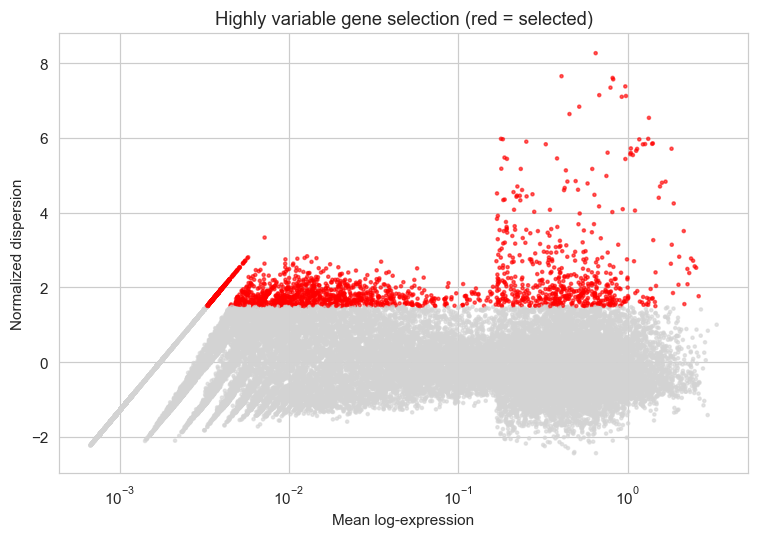


Pseudobulk after HVG selection: (68, 2000)


In [30]:
# Identify HVGs from the per-cell (not pseudobulk) data 
sc.pp.highly_variable_genes(adata_sec, n_top_genes=2000, flavor="seurat")
hvg_mask = adata_sec.var["highly_variable"].values
hvg_names = adata_sec.var_names[hvg_mask].tolist()

print(f"Selected {hvg_mask.sum()} highly variable genes")

# Visualize the HVG selection
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(adata_sec.var["means"], adata_sec.var["dispersions_norm"],
           c=adata_sec.var["highly_variable"].map({True: "red", False: "lightgray"}),
           s=4, alpha=0.6)
ax.set_xlabel("Mean log-expression")
ax.set_ylabel("Normalized dispersion")
ax.set_title("Highly variable gene selection (red = selected)")
ax.set_xscale("log")
plt.tight_layout()
plt.show()

# Restrict pseudobulk to HVGs only
pseudo_hvg = pseudo[hvg_names]
print(f"\nPseudobulk after HVG selection: {pseudo_hvg.shape}")

In [31]:
top_var = adata_sec.var.sort_values("dispersions_norm", ascending=False).head(10)
print(top_var[["means", "dispersions_norm", "highly_variable"]])

                             means  dispersions_norm  highly_variable
gene                                                                 
SARSCoV2-E                0.648423          8.269567             True
SARSCoV2-Unspliced-ORF7a  0.407563          7.653196             True
SARSCoV2-nsp7             0.816555          7.607373             True
SARSCoV2-ORF8             0.823263          7.569210             True
SARSCoV2-nsp5             0.970366          7.380121             True
SARSCoV2-ORF6             0.793134          7.346900             True
SARSCoV2-nsp9             0.680655          7.146335             True
SARSCoV2-M                0.978684          7.123474             True
SARSCoV2-nsp10            0.924393          7.101411             True
MT-ND6                    0.518484          6.836690             True


## 2.7 — Scale features (z-score per gene), then PCA

Two steps before PCA:

1. **Scale** each gene to zero mean and unit variance. PCA finds directions of maximum
   variance, so without scaling, genes with naturally high variance (regardless of biology)
   will dominate the first PCs.
2. **PCA** down to 50 components.

In [32]:
# Standardize per gene
scaler = StandardScaler()
pseudo_scaled = scaler.fit_transform(pseudo_hvg)
print(f"Scaled matrix shape: {pseudo_scaled.shape}")
print(f"Per-gene means after scaling (should be ~0): {pseudo_scaled.mean(axis=0)[:5]}")
print(f"Per-gene std after scaling (should be ~1):  {pseudo_scaled.std(axis=0)[:5]}")

# PCA — use min(50, n_patients - 1) components
n_pcs = min(50, pseudo_scaled.shape[0] - 1)
pca = PCA(n_components=n_pcs, random_state=42)
pca_scores = pca.fit_transform(pseudo_scaled)
print(f"\nPCA output shape: {pca_scores.shape}  (patients × PCs)")

Scaled matrix shape: (68, 2000)
Per-gene means after scaling (should be ~0): [ 5.6098489e-08  7.4067536e-08 -5.8289835e-08 -4.1416463e-08
 -4.1197328e-08]
Per-gene std after scaling (should be ~1):  [1.         1.0000001  0.99999994 0.9999997  0.99999994]

PCA output shape: (68, 50)  (patients × PCs)


## 2.8 — Scree plot: how much variance does each PC capture?

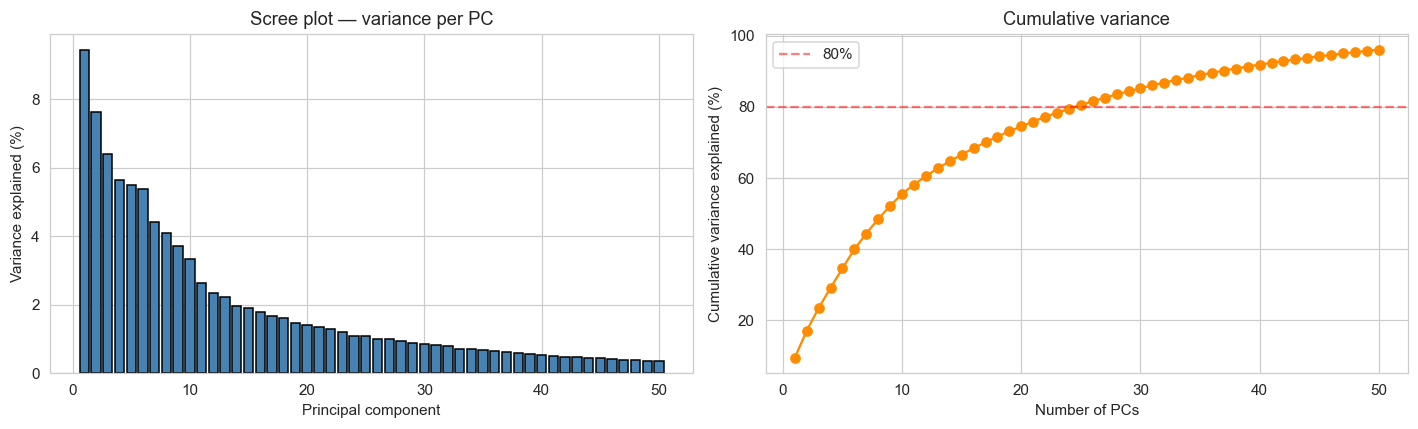

Top 5 PCs capture 34.6% of variance
Top 20 PCs capture 74.5% of variance
All 50 PCs capture 96.2% of variance


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, n_pcs + 1), pca.explained_variance_ratio_ * 100,
            color="steelblue", edgecolor="black")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("Scree plot — variance per PC")

axes[1].plot(range(1, n_pcs + 1), np.cumsum(pca.explained_variance_ratio_) * 100,
             marker="o", color="darkorange")
axes[1].axhline(80, color="red", linestyle="--", alpha=0.5, label="80%")
axes[1].set_xlabel("Number of PCs")
axes[1].set_ylabel("Cumulative variance explained (%)")
axes[1].set_title("Cumulative variance")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Top 5 PCs capture {(pca.explained_variance_ratio_[:5].sum() * 100):.1f}% of variance")
print(f"Top 20 PCs capture {(pca.explained_variance_ratio_[:20].sum() * 100):.1f}% of variance")
print(f"All {n_pcs} PCs capture {(pca.explained_variance_ratio_.sum() * 100):.1f}% of variance")

## 2.9 — The key visualization: do severe and not-severe separate in PC space?

This is the **moment of truth**. If severity correlates with the dominant variance in
Secretory expression, you'll see two clearly separated groups in the PC1–PC2 plot. If
severity is mixed up with other signals (variant, batch, individual variation), the groups
will overlap — which is what we'd expect in noisy biological data.

C:\Users\marya\AppData\Local\Temp\ipykernel_29100\297734208.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


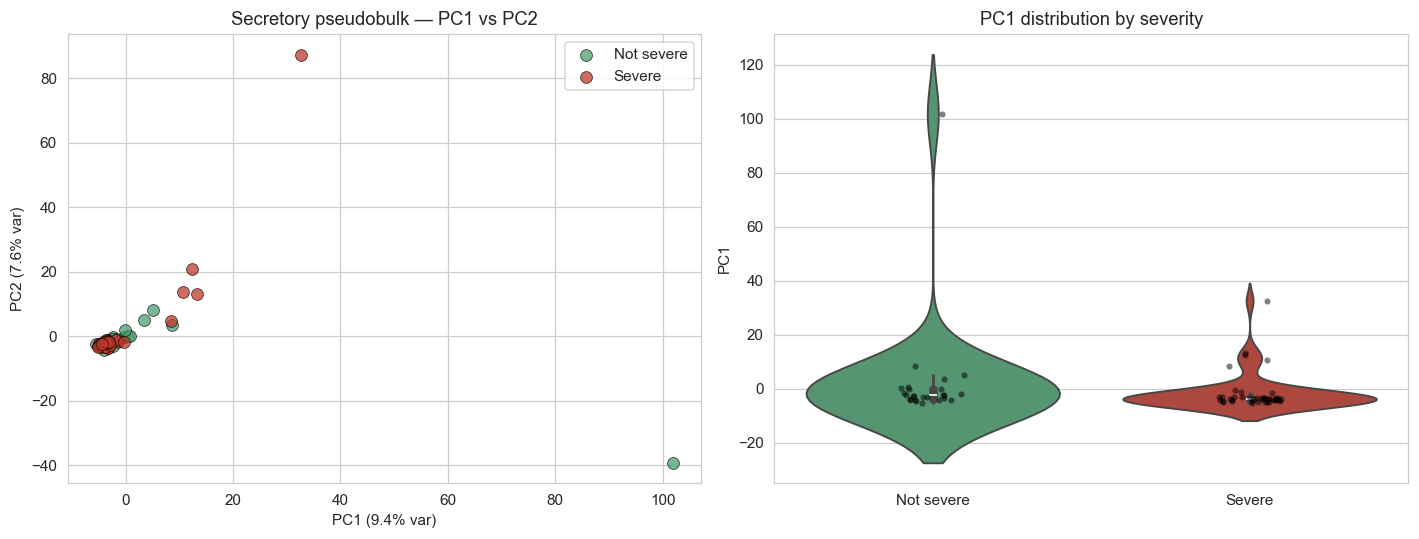

In [34]:
pca_df = pd.DataFrame(
    pca_scores,
    index=pseudo.index,
    columns=[f"PC{i+1}" for i in range(n_pcs)],
)
pca_df["severity"] = labels.values
pca_df["severity_label"] = pca_df["severity"].map({0: "Not severe", 1: "Severe"})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PC1 vs PC2 scatter
for sev, color in zip(["Not severe", "Severe"], ["#4C9F70", "#C0392B"]):
    sub = pca_df[pca_df["severity_label"] == sev]
    axes[0].scatter(sub["PC1"], sub["PC2"], c=color, label=sev, s=60, alpha=0.75,
                    edgecolor="black", linewidth=0.5)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
axes[0].set_title("Secretory pseudobulk — PC1 vs PC2")
axes[0].legend()

# PC1 distribution by severity
sns.violinplot(
    data=pca_df, x="severity_label", y="PC1",
    order=["Not severe", "Severe"],
    palette={"Not severe": "#4C9F70", "Severe": "#C0392B"},
    inner="box", ax=axes[1],
)
sns.stripplot(
    data=pca_df, x="severity_label", y="PC1",
    order=["Not severe", "Severe"],
    color="black", size=4, alpha=0.5, ax=axes[1],
)
axes[1].set_title("PC1 distribution by severity")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

No clear severity signal in PC1 alone.
We will use all 50 PCs together in task 3, so even if PC1 alone doesn't separate groups, a combination of PCs might!!

Try the same plot for PC2 vs PC3, PC3 vs PC4 etc. , sometimes the severity signal lives in a later PC, not in PC1.

## 2.10 — Which genes drive PC1? (loadings)

PCA isn't a black box; each PC is a weighted sum of genes. The top-weighted genes for PC1
tell you what biology PC1 represents.

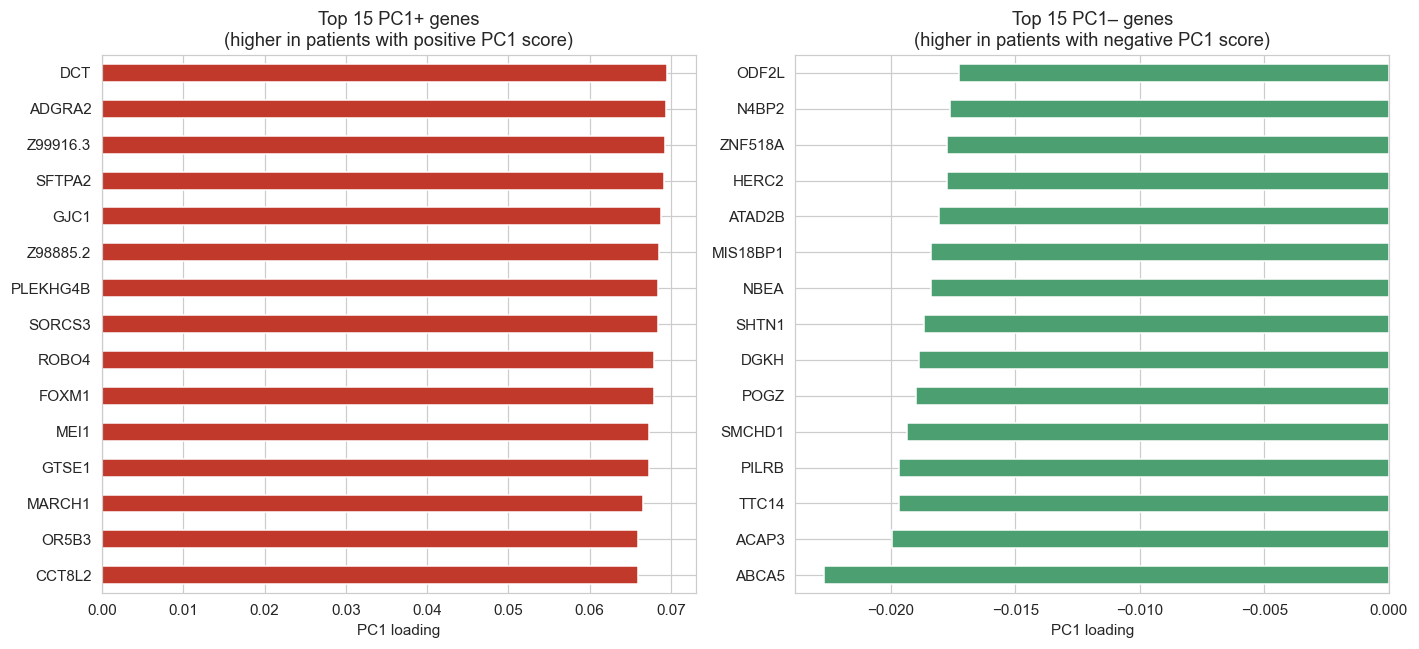

Top 10 PC1+ genes: ['DCT', 'ADGRA2', 'Z99916.3', 'SFTPA2', 'GJC1', 'Z98885.2', 'PLEKHG4B', 'SORCS3', 'ROBO4', 'FOXM1']
Top 10 PC1– genes: ['ABCA5', 'ACAP3', 'TTC14', 'PILRB', 'SMCHD1', 'POGZ', 'DGKH', 'SHTN1', 'NBEA', 'MIS18BP1']


In [35]:
loadings = pd.Series(pca.components_[0], index=hvg_names).sort_values()
top_neg = loadings.head(15)  # genes with the most negative loading
top_pos = loadings.tail(15)  # genes with the most positive loading

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
top_pos.plot(kind="barh", color="#C0392B", ax=axes[0])
axes[0].set_title("Top 15 PC1+ genes\n(higher in patients with positive PC1 score)")
axes[0].set_xlabel("PC1 loading")

top_neg.plot(kind="barh", color="#4C9F70", ax=axes[1])
axes[1].set_title("Top 15 PC1– genes\n(higher in patients with negative PC1 score)")
axes[1].set_xlabel("PC1 loading")
plt.tight_layout()
plt.show()

# Show the top genes as a list too
print("Top 10 PC1+ genes:", top_pos.tail(10).index.tolist()[::-1])
print("Top 10 PC1– genes:", top_neg.head(10).index.tolist())

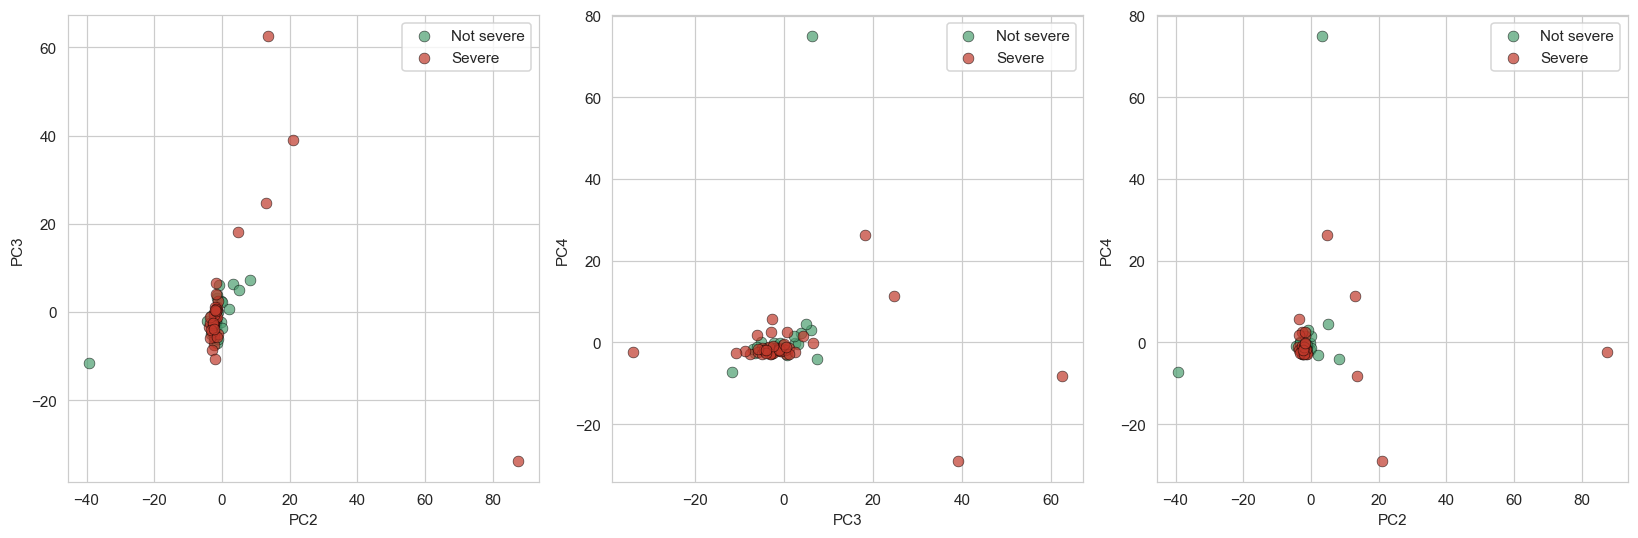

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (pc_x, pc_y) in zip(axes, [("PC2", "PC3"), ("PC3", "PC4"), ("PC2", "PC4")]):
    for sev, color in zip(["Not severe", "Severe"], ["#4C9F70", "#C0392B"]):
        sub = pca_df[pca_df["severity_label"] == sev]
        ax.scatter(sub[pc_x], sub[pc_y], c=color, label=sev, s=50, alpha=0.7,
                   edgecolor="black", linewidth=0.4)
    ax.set_xlabel(pc_x)
    ax.set_ylabel(pc_y)
    ax.legend()
plt.tight_layout()
plt.show()

This interprets what PC1 biologically represents. Each gene gets a loading — essentially a weight for how much it drives PC1. PC1+ genes (DCT, FOXM1, GTSE1, SFTPA2...) tend to be stress, proliferation, and lung-function genes.  PC1− genes (ABCA5, SMCHD1, POGZ...) lean toward chromatin regulation. The key thing to notice is that the positive loadings (~0.07) are much larger in magnitude than the negative ones (~0.02), meaning the PC1+ genes dominate the axis — which is likely being pulled by those few extreme outlier patients.
The bottom line: PC1 alone doesn't cleanly distinguish disease severity, but it does represent a real biological axis (something like "secretory cell stress/proliferation state").

## 2.11 — Save the pseudobulk + PCA for Task 3

In [39]:
# Save the pseudobulk pre-PCA (in case we want to retry with different normalization)
pseudo_hvg.to_csv(f"step2_{CELL_TYPE}_pseudobulk_hvg.csv")

# Save the PCA scores + labels (this is what Task 3 will load)
pca_df_to_save = pca_df.drop(columns=["severity_label"])
pca_df_to_save.to_csv(f"step2_{CELL_TYPE}_pca.csv")

# Save the PCA loadings for biological interpretation
pd.DataFrame(
    pca.components_, columns=hvg_names,
    index=[f"PC{i+1}" for i in range(n_pcs)],
).to_csv(f"step2_{CELL_TYPE}_pca_loadings.csv")

print(f"Saved 3 files:")
print(f"  step2_{CELL_TYPE}_pseudobulk_hvg.csv  — {pseudo_hvg.shape}")
print(f"  step2_{CELL_TYPE}_pca.csv             — {pca_df_to_save.shape}")
print(f"  step2_{CELL_TYPE}_pca_loadings.csv    — {n_pcs} PCs × {len(hvg_names)} genes")

Saved 3 files:
  step2_Secretory_pseudobulk_hvg.csv  — (68, 2000)
  step2_Secretory_pca.csv             — (68, 51)
  step2_Secretory_pca_loadings.csv    — 50 PCs × 2000 genes
